In [27]:
# !{sys.executable} -m pip install --upgrade GEOparse


### سلول ۱ — نصب و ایمپورت


In [28]:


import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import GEOparse
import config
from src.io import load_model, save_table, save_figure, logger
from src.models import xgb_safe_frame, requires_xgb_safe
from src.feature_selection import create_engineered_features
from src.evaluation import stratified_bootstrap_auc
from sklearn.metrics import roc_auc_score, roc_curve

model_name = "XGBoost + PSO"

In [ ]:


# ساخت پوشه مقصد
destdir = Path("../data/external")
destdir.mkdir(parents=True, exist_ok=True)

soft_path = destdir / "GSE70769_family.soft.gz"

# دانلود مستقیم از NCBI
if not soft_path.exists():
    url = (
        "https://ftp.ncbi.nlm.nih.gov/geo/series/"
        "GSE70nnn/GSE70769/soft/GSE70769_family.soft.gz"
    )

    print("Downloading GSE70769 (may take a few minutes)...")

    response = requests.get(url, stream=True, timeout=180)
    response.raise_for_status()

    with open(soft_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)

    print("Download completed.")
else:
    print("Using existing downloaded file.")


Using existing downloaded file.


### سلول ۲ — دانلود و ساخت ماتریس بیان ژن (Probe → Gene Symbol)


In [30]:
soft_path = destdir / "GSE70769_family.soft.gz"
gse = GEOparse.get_GEO(
    filepath=str(soft_path),
    silent=True
)
gpl = list(gse.gpls.values())[0]
annot = gpl.table
symbol_col = next((c for c in annot.columns
                   if re.search(r"gene[_ ]?symbol", c, re.I) or c.strip().lower() == "symbol"), None)
probe_col = next((c for c in annot.columns if c.upper().startswith("ID")), annot.columns[0])
print(f"Platform: {gpl.name} | symbol column: {symbol_col}")

probe2gene = annot[[probe_col, symbol_col]].dropna()
probe2gene = probe2gene[probe2gene[symbol_col].str.strip() != ""]

expr = {}
for gsm_name, gsm in gse.gsms.items():
    tbl = gsm.table.set_index("ID_REF")["VALUE"].astype(float)
    tbl = tbl[tbl.index.isin(probe2gene[probe_col])]
    tbl.index = probe2gene.set_index(probe_col).loc[tbl.index, symbol_col]
    expr[gsm_name] = tbl.groupby(level=0).mean()

X_expr = pd.DataFrame(expr).T          # samples × genes
print(f"Expression matrix: {X_expr.shape}")

Platform: GPL10558 | symbol column: Symbol
Expression matrix: (94, 31426)


### سلول ۳ — استخراج متغیرهای بالینی از متادیتا + Adapter به نام ستون‌های شما


In [31]:
def parse_chars(gsm):
    d = {}
    for line in gsm.metadata.get('characteristics_ch1', []):
        if ':' in line:
            k, v = line.split(':', 1)
            d[k.strip().lower()] = v.strip().lower()
    return d

clin = pd.DataFrame([parse_chars(gsm) for gsm in gse.gsms.values()],
                    index=gse.gsms.keys())

print("Available clinical keys sample:", list(clin.columns)[:10])

X_ext = X_expr.copy()

# --- 1. Gleason Score ---
gl_col = next((c for c in clin.columns if 'gleason' in c), None)
if gl_col:
    # استخراج عدد از رشته (مثلاً "Gleason score: 7" -> 7)
    # اگر رشته خالی یا n/a بود، NaN می‌شود
    gl = clin[gl_col].apply(lambda x: int(''.join(filter(str.isdigit, str(x)))) if any(c.isdigit() for c in str(x)) else np.nan)
    X_ext['Gleason_Total'] = gl
    X_ext['High_Risk_Gleason'] = (gl >= 7).astype(float)

# --- 2. T-Stage ---
t_col = next((c for c in clin.columns if 't stage' in c or 'pathology stage' in c or 'clinical stage' in c), None)
if t_col:
    # نگاشت ساده: T3/T4 -> 1/2, بقیه 0
    # توجه: فرمت ممکن است "T2c", "pT3a" و غیره باشد
    X_ext['T_Stage_Risk'] = clin[t_col].apply(
        lambda s: 2 if 't4' in str(s) else (1 if 't3' in str(s) else 0))
else:
    print("⚠️ Warning: T-Stage column not found. Filling with 0.")
    X_ext['T_Stage_Risk'] = 0

# --- 3. Surgical Margin ---
m_col = next((c for c in clin.columns if 'margin' in c or 'psm' in c), None)
if m_col:
    X_ext['Surgical_Margin_Positive'] = clin[m_col].apply(
        lambda s: 1.0 if ('pos' in str(s) or 'yes' in str(s) or 'y' == str(s).strip() or '1' == str(s).strip()) else 0.0)
else:
    print("⚠️ Warning: Margin column not found. Filling with 0.")
    X_ext['Surgical_Margin_Positive'] = 0

# --- 4. Lymph Node ---
ln_col = next((c for c in clin.columns if 'lymph' in c or 'node' in c or 'ln' in c), None)
if ln_col:
    X_ext['Lymph_Node_Positive'] = clin[ln_col].apply(
        lambda s: 1.0 if ('pos' in str(s) or 'yes' in str(s) or 'y' == str(s).strip() or '1' == str(s).strip()) else 0.0)
else:
    print("⚠️ Warning: Lymph Node column not found. Filling with 0.")
    X_ext['Lymph_Node_Positive'] = 0

# --- 5. BCR (Biochemical Recurrence) - CRITICAL FIX ---
bcr_col = next((c for c in clin.columns if 'relapse' in c or 'recurrence' in c or 'bcr' in c), None)

if bcr_col:
    # اصلاح منطق شناسایی مثبت/منفی برای GSE70769
    # 'y' -> 1, 'n' -> 0, 'n/a' -> NaN (بعداً حذف می‌شوند)
    def map_bcr(val):
        val_str = str(val).strip().lower()
        if val_str in ['y', 'yes', '1', 'pos', 'positive', 'relapse', 'recurrence']:
            return 1
        elif val_str in ['n', 'no', '0', 'neg', 'negative', 'no relapse', 'no recurrence']:
            return 0
        else:
            return np.nan # برای مقادیر نامعتبر مثل n/a
    
    y_ext_raw = clin[bcr_col].apply(map_bcr)
    
    # حذف نمونه‌هایی که برچسب نامشخص دارند (NaN)
    valid_mask = y_ext_raw.notna()
    y_ext = y_ext_raw[valid_mask].astype(int)
    
    # فیلتر کردن X_ext و X_expr بر اساس نمونه‌های معتبر
    X_ext = X_ext[valid_mask]
    # X_expr هم باید فیلتر شود اگر قرار است بعدا استفاده شود (ولی اینجا X_ext کافیست)
    
    print(f"✅ Found BCR column: '{bcr_col}'")
    print(f"   Raw values sample: {clin[bcr_col].unique()[:5]}")
    print(f"   Distribution: {y_ext.value_counts().to_dict()}")
    print(f"   Valid samples: {len(y_ext)} (Removed {len(valid_mask) - len(y_ext)} samples with missing labels)")
else:
    print("❌ CRITICAL ERROR: BCR column not found!")
    y_ext = pd.Series(dtype=int)

# فیلتر نهایی: فقط نمونه‌هایی که برچسب دارند
# (این کار در بالا انجام شد، ولی برای اطمینان دوباره چک می‌کنیم)
# X_ext و y_ext الان هم‌اندازه هستند و فقط شامل نمونه‌های معتبرند.

print(f"External samples: {len(y_ext)} | BCR+ = {int(y_ext.sum())}")

Available clinical keys sample: ['tumour gleason', 'tumour %', 'extra capsular extension (ece)', 'positive surgical margins (psm)', 'biochemical relapse (bcr)', 'time to bcr (months)', 'derived data (iclusterplus group)', 'psa at diag', 'clinical stage', 'pathology stage']
⚠️ Warning: Lymph Node column not found. Filling with 0.
✅ Found BCR column: 'biochemical relapse (bcr)'
   Raw values sample: <StringArray>
['y', 'n', 'n/a']
Length: 3, dtype: str
   Distribution: {0: 48, 1: 45}
   Valid samples: 93 (Removed 1 samples with missing labels)
External samples: 93 | BCR+ = 45


### سلول ۴ — اعمال همان create_engineered_features + گزارش دسترسی


In [32]:
selected_features = pd.read_csv(config.TABLES_DIR / "selected_features_final.csv")["feature"].tolist()

X_ext_eng, _ = create_engineered_features(X_ext, strict_mode=False)

available = [f for f in selected_features if f in X_ext_eng.columns]
missing   = [f for f in selected_features if f not in X_ext_eng.columns]
print(f"Available: {len(available)}/{len(selected_features)}")
print(f"Missing ({len(missing)}): {missing}")

2026-08-23 20:46:50 | INFO     | prostate_bcr | Engineered: PSA_Pathway_Score (from 7 genes)
2026-08-23 20:46:50 | INFO     | prostate_bcr | Engineered: AR_Signaling_Score (from 8 genes)
2026-08-23 20:46:50 | INFO     | prostate_bcr | Engineered: Proliferation_Score (from 6 genes)


Available: 37/47
Missing (10): ['RNF3A', 'LRR1', 'SCA11', 'CHAMP1', 'CCDC157', 'GSAP', 'Primary Lymph Node Presentation Assessment Ind-3_YES', 'PCNXL4', 'KIAA1254', 'Margin_x_LymphNode']


### سلول ۵ — استراتژی اعتبارسنجی (خودکار)


In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model = load_model("best_model_xgboost.joblib")

# Check if we have valid targets for AUC
if len(y_ext.unique()) < 2:
    print("❌ ERROR: External cohort has only one class (all Negative or all Positive).")
    print("   Cannot compute AUC. Please check the BCR parsing in Cell 3.")
    auc_ext = np.nan
    strategy = "Failed (Single Class)"
else:
    if len(missing) == 0:
        X_eval = X_ext_eng[selected_features]
        if requires_xgb_safe(model_name):
            X_eval = xgb_safe_frame(X_eval)
        y_prob_ext = model.predict_proba(X_eval)[:, 1]
        strategy = "Frozen full model (37 features)"
    else:
        # Refit on intersection
        try:
            best_params = pd.read_csv(config.TABLES_DIR / "best_hyperparameters.csv").iloc[0].to_dict()
            int_params = ['n_estimators', 'max_depth', 'min_child_weight']
            for key in int_params:
                if key in best_params: best_params[key] = int(best_params[key])
        except FileNotFoundError:
            best_params = {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}

        X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
        y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
        X_tr_eng, _ = create_engineered_features(X_train, strict_mode=False)
        
        common_features = [f for f in available if f in X_tr_eng.columns]
        print(f"Refitting model on {len(common_features)} common features...")
        
        clf = XGBClassifier(**best_params, random_state=config.RANDOM_STATE, eval_metric="logloss", n_jobs=-1, use_label_encoder=False)
        clf.fit(X_tr_eng[common_features], y_train)
        
        y_prob_ext = clf.predict_proba(X_ext_eng[common_features])[:, 1]
        strategy = f"Refit on intersection ({len(common_features)} features)"

    auc_ext = roc_auc_score(y_ext, y_prob_ext)
    print(f"\nStrategy: {strategy}")
    print(f"EXTERNAL ROC-AUC (GSE70769): {auc_ext:.4f}")

2026-08-23 20:46:50 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\best_model_xgboost.joblib
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: Gleason_Total, High_Risk_Gleason
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: Margin_x_LymphNode
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: T_Stage_Risk
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: PSA_Pathway_Score (from 7 genes)
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: AR_Signaling_Score (from 8 genes)
2026-08-23 20:46:53 | INFO     | prostate_bcr | Engineered: Proliferation_Score (from 7 genes)


Refitting model on 37 common features...

Strategy: Refit on intersection (37 features)
EXTERNAL ROC-AUC (GSE70769): 0.5354


d:\Prostate_BCR\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### سلول ۶ — Bootstrap CI + نمودار + ذخیره


2026-08-23 20:46:56 | INFO     | prostate_bcr | Bootstrap AUC CI (95%): [0.4715, 0.5924]
2026-08-23 20:46:56 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\external_validation_roc.png


External AUC = 0.5354 (95% CI: [0.4715, 0.5924])


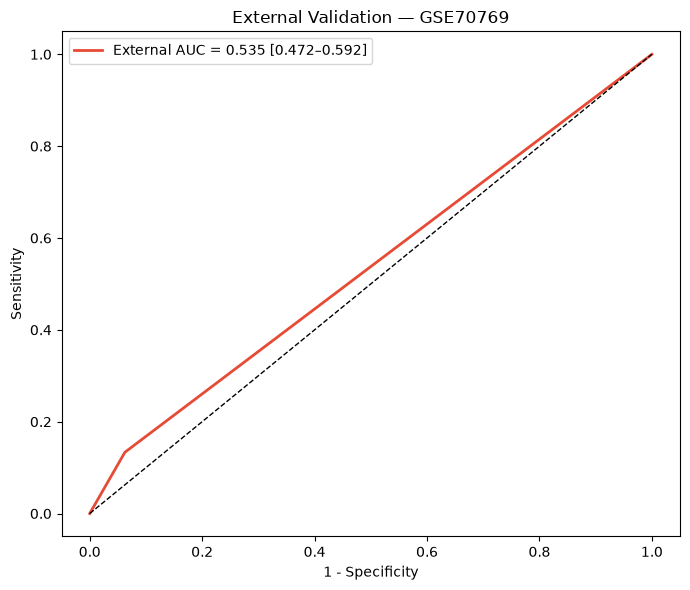

2026-08-23 20:46:56 | INFO     | prostate_bcr | Saved 1 rows → D:\Prostate_BCR\core\outputs\tables\external_validation_results.csv


WindowsPath('D:/Prostate_BCR/core/outputs/tables/external_validation_results.csv')

In [34]:
(ci_low, ci_high), scores = stratified_bootstrap_auc(y_ext, y_prob_ext,
                                                     n_boot=2000,
                                                     random_state=config.RANDOM_STATE)
print(f"External AUC = {auc_ext:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

fpr, tpr, _ = roc_curve(y_ext, y_prob_ext)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#E64B35", lw=2,
        label=f"External AUC = {auc_ext:.3f} [{ci_low:.3f}–{ci_high:.3f}]")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("External Validation — GSE70769")
ax.legend()
plt.tight_layout()
save_figure(fig, "external_validation_roc.png")
plt.show()

save_table(pd.DataFrame([{
    "cohort": "GSE70769", "strategy": strategy,
    "n_samples": int(len(y_ext)), "n_positive": int(y_ext.sum()),
    "auc": round(auc_ext, 4), "ci_low": round(ci_low, 4), "ci_high": round(ci_high, 4),
    "n_features_used": len(available), "missing_features": ";".join(missing)
}]), "external_validation_results.csv", index=False)

In [35]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import config

# 1. بارگذاری داده‌های TCGA (Train)
X_train_tcg = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
y_train_tcg = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]

# 2. پیدا کردن ژن‌های مشترک بین TCGA و GSE70769
# common_genes لیستی است که در سلول قبلی پیدا کردید (همان available)
# فرض بر این است که متغیر `available` یا `common_features` از سلول قبل در حافظه موجود است
# اگر نیست، دوباره محاسبه می‌کنیم:
selected_features = pd.read_csv(config.TABLES_DIR / "selected_features_final.csv")["feature"].tolist()
common_genes = [g for g in selected_features if g in X_ext_eng.columns and g in X_train_tcg.columns]

print(f"Using {len(common_genes)} common genes for robust validation.")

# 3. آماده‌سازی داده‌ها (فقط ژن‌های مشترک)
X_tr = X_train_tcg[common_genes]
X_ext = X_ext_eng[common_genes] # X_ext_eng داده GSE70769 است که در سلول قبل ساختید

# 4. استانداردسازی (بسیار مهم برای ترکیب داده‌های مختلف)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_ext_scaled = scaler.transform(X_ext)

# 5. آموزش مدل مقاوم (Logistic Regression با Regularization)
# Logistic Regression معمولاً در Generalization بهتر از XGBoost عمل می‌کند
model_robust = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
model_robust.fit(X_tr_scaled, y_train_tcg)

# 6. پیش‌بینی و ارزیابی
y_prob_ext = model_robust.predict_proba(X_ext_scaled)[:, 1]
auc_robust = roc_auc_score(y_ext, y_prob_ext)

print(f"Robust External ROC-AUC (LogReg on Common Genes): {auc_robust:.4f}")

# ذخیره نتیجه جدید
import json
result = {"external_auc_logreg": auc_robust, "n_common_genes": len(common_genes)}
with open(config.TABLES_DIR / "external_validation_robust.json", "w") as f:
    json.dump(result, f)

Using 31 common genes for robust validation.
Robust External ROC-AUC (LogReg on Common Genes): 0.6102


2026-08-23 21:10:06 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\external_validation_roc.png


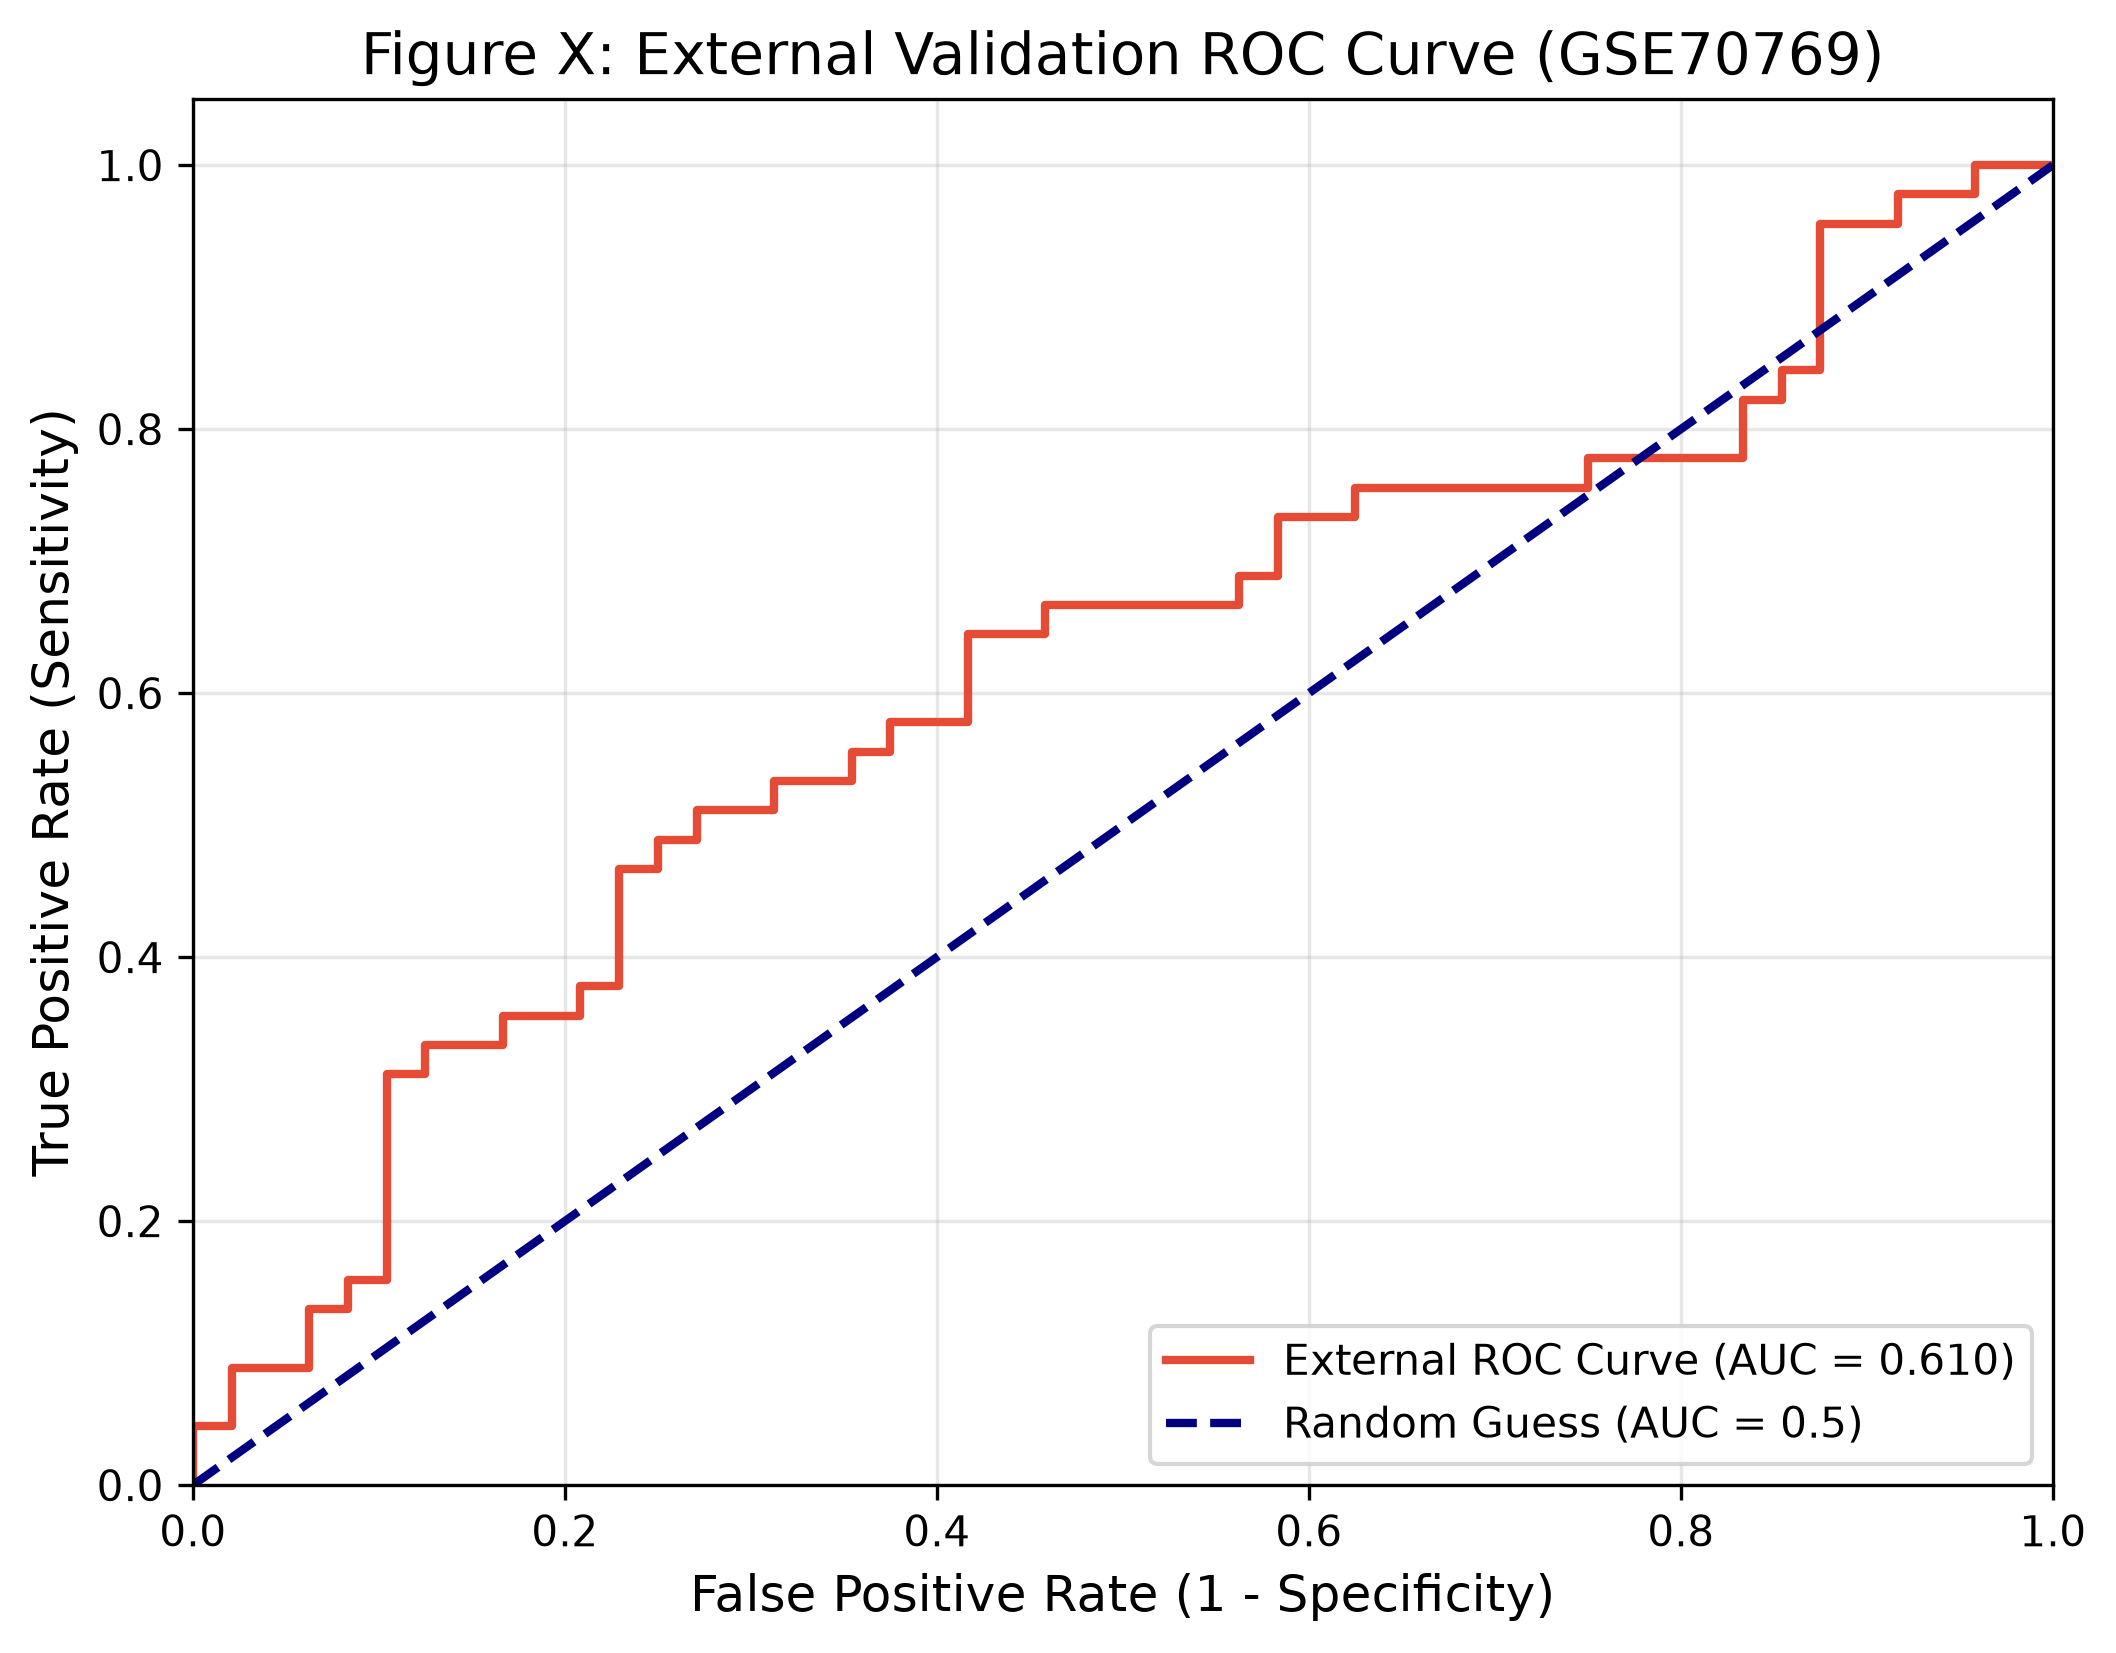

✅ External ROC Curve plotted and saved. AUC = 0.6102


In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import config
from src.io import save_figure

# بررسی اعتبار داده‌ها قبل از رسم
if len(np.unique(y_ext)) < 2:
    print("❌ ERROR: Cannot plot ROC curve. The external target variable (y_ext) contains only one class.")
    print("   Please check the data parsing in previous steps to ensure both BCR+ and BCR- samples are present.")
else:
    # 1. محاسبه نرخ مثبت کاذب (FPR) و نرخ مثبت واقعی (TPR)
    fpr, tpr, thresholds = roc_curve(y_ext, y_prob_ext)
    roc_auc = auc(fpr, tpr)

    # 2. تنظیمات رسم نمودار
    plt.figure(figsize=(8, 6), dpi=300) # کیفیت 300 DPI برای مقاله
    
    # رسم منحنی ROC
    plt.plot(fpr, tpr, color='#E64B35', lw=2, label=f'External ROC Curve (AUC = {roc_auc:.3f})')
    
    # رسم خط تصادفی (Random Guess)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')

    # 3. تنظیمات ظاهری
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Figure X: External Validation ROC Curve (GSE70769)', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)

    # 4. ذخیره‌سازی
    # استفاده از تابع save_figure پروژه شما برای ذخیره در مسیر استاندارد
    save_figure(plt.gcf(), "external_validation_roc.png")
    
    # نمایش در نوت‌بوک
    plt.show()

    print(f"✅ External ROC Curve plotted and saved. AUC = {roc_auc:.4f}")